In [108]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame  # prêt à l'emploi

In [109]:
df.to_csv('california_housing.csv', index=False)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


**Présentation du dataset**


Source : California Housing Dataset, issu du recensement américain de 1990. Initialement publié par R. Kelley Pace et Ronald Barry (1997) dans la revue Statistics & Education. Le jeu de données est disponible directement via sklearn.datasets.
fetch_california_housing (documentation scikit-learn).
Le California Housing Dataset est sous licence BSD-like via scikit-learn
Description : Le dataset contient 20 640 observations correspondant à des blocs de recensement (districts) en Californie. Chaque observation est décrite par 8 variables explicatives, toutes numériques continues :
VariableDescriptionMedIncRevenu médian des ménages du district (en dizaines de milliers de dollars)HouseAgeÂge médian des logements du district (en années)AveRoomsNombre moyen de pièces par logementAveBedrmsNombre moyen de chambres par logementPopulationPopulation totale du districtAveOccupNombre moyen d'occupants par logementLatitudeLatitude géographique du districtLongitudeLongitude géographique du district
Variable cible : MedHouseVal — prix médian des logements du district, exprimé en centaines de milliers de dollars (× 100k dollars). Cette variable est plafonnée à 5.0 ($500 000).
Objectif du projet : Appliquer une démarche de régression linéaire multiple afin de prédire le prix médian des logements (MedHouseVal) à partir des 8 variables explicatives disponibles. Le modèle sera évalué à l'aide des métriques MAE, RMSE et R².

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [112]:
import sys
import sklearn
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns

print(f"Python     : {sys.version}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print(f"seaborn     : {sns.__version__}")

Python     : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
scikit-learn: 1.6.1
pandas      : 2.2.2
numpy       : 2.0.2
matplotlib  : 3.10.0
seaborn     : 0.13.2


Exploration et préparation des données

Aperçu général et statistiques descriptives
Nous commençons par examiner la structure du jeu de données (types, dimensions) ainsi que les principales statistiques descriptives afin d'identifier d'éventuelles anomalies.

In [113]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [114]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [115]:
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing)
print(f"\nTotal : {missing.sum()} valeur(s) manquante(s)")

Valeurs manquantes par colonne :
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total : 0 valeur(s) manquante(s)


Observations :

Le dataset ne contient aucune valeur manquante, ce qui simplifie la phase de pré-traitement.

Les 9 variables sont toutes de type float64 : aucun encodage catégoriel n'est nécessaire.

Les échelles sont très hétérogènes : MedInc varie de 0.5 à 15, tandis que Population atteint 35 682. Une standardisation sera donc indispensable avant la modélisation.

AveOccup présente un écart-type très élevé (≈ 10.4) par rapport à sa moyenne (≈ 3.1), ce qui suggère la présence de valeurs aberrantes.

MedHouseVal a un maximum fixé à 5.001, confirmant le plafonnement évoqué. La médiane (1.80) est inférieure à la moyenne (2.07), indiquant une distribution asymétrique à droite.

Nous visualisons la distribution de la variable cible ainsi que des 8 features afin de détecter les asymétries, les valeurs extrêmes et les éventuels pics de fréquence.

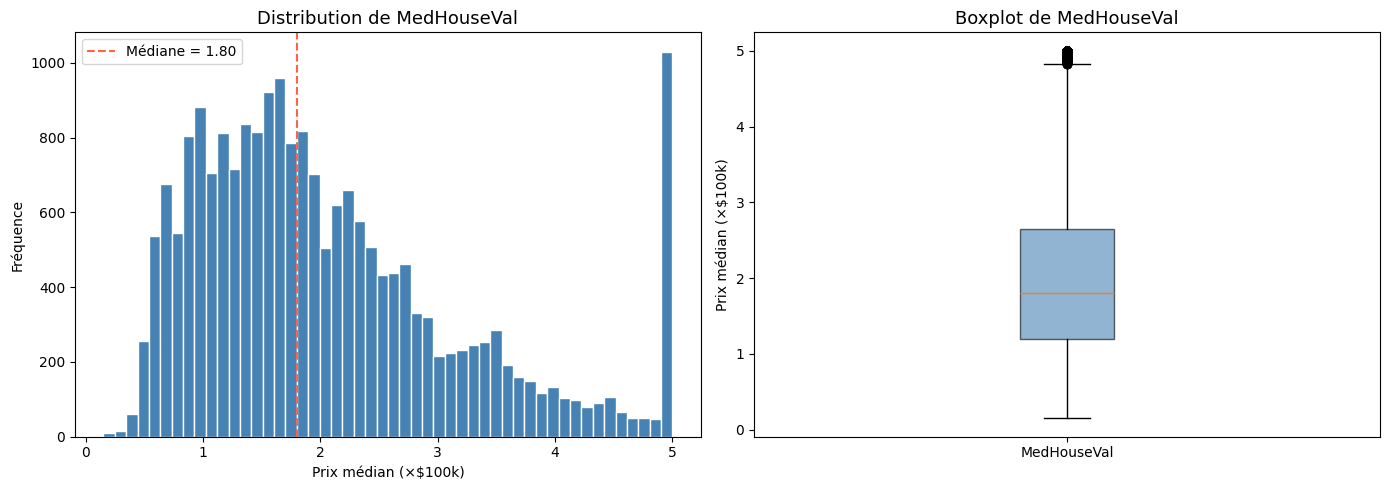

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['MedHouseVal'].median(), color='tomato', linestyle='--',
                label=f"Médiane = {df['MedHouseVal'].median():.2f}")
axes[0].set_title('Distribution de MedHouseVal', fontsize=13)
axes[0].set_xlabel('Prix médian (×$100k)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de MedHouseVal', fontsize=13)
axes[1].set_ylabel('Prix médian (×$100k)')
axes[1].set_xticklabels(['MedHouseVal'])

plt.tight_layout()
plt.show()

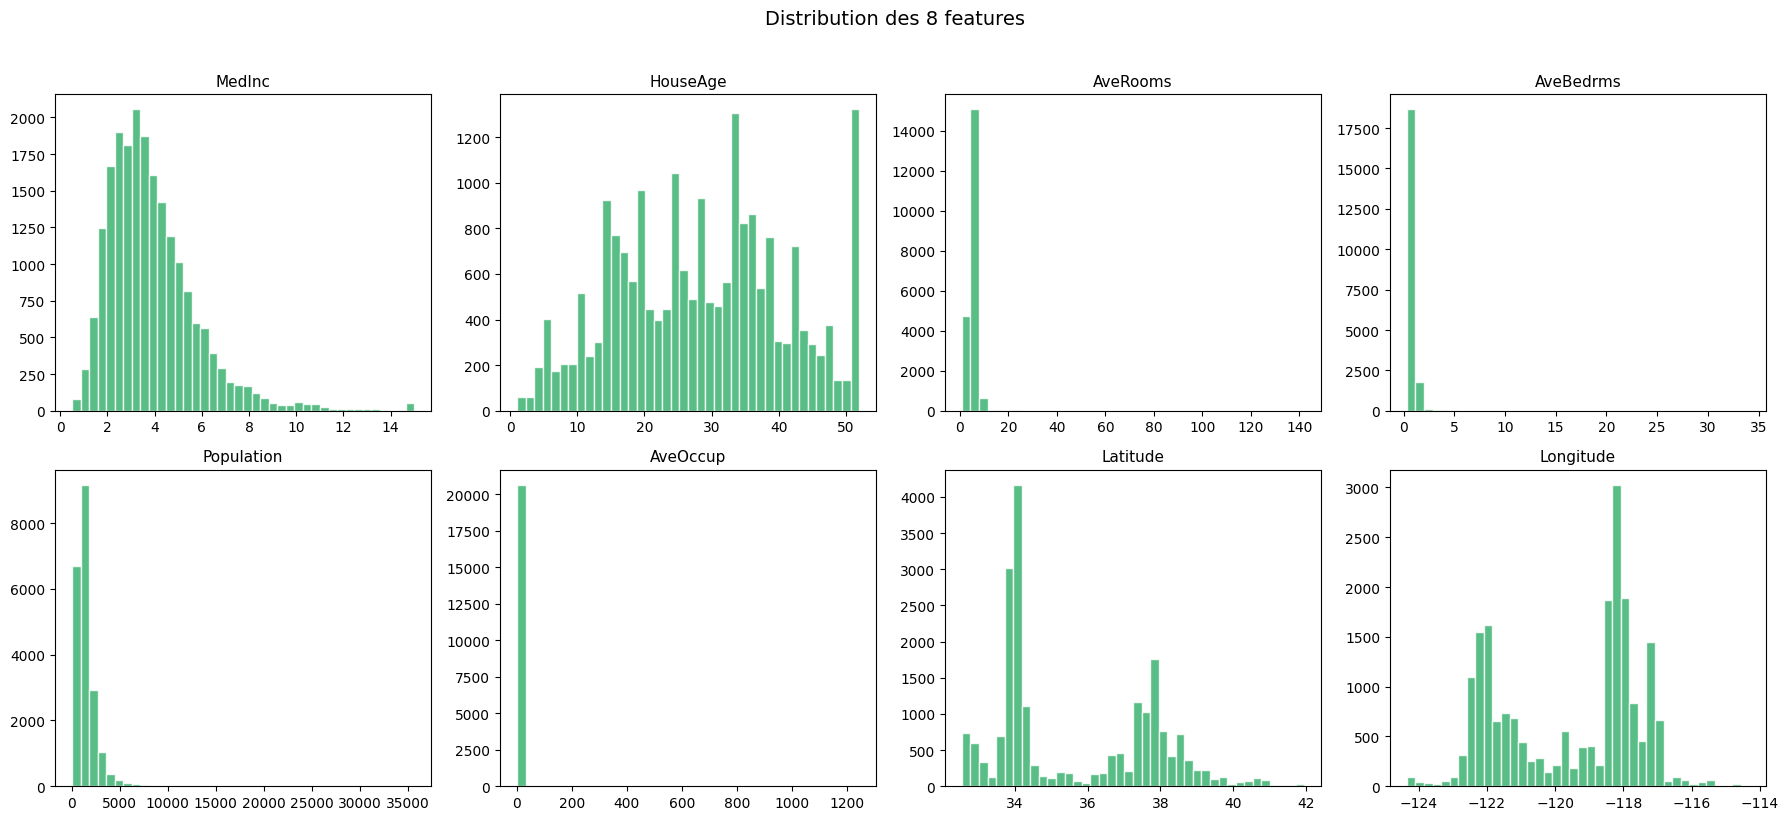

In [117]:
features = [c for c in df.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Distribution des 8 features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Interprétation :

MedHouseVal présente un pic anormal à 5.0 (valeur plafond), ce qui signifie que de nombreux districts dont le prix réel dépasse $500k sont artificiellement regroupés. Cela constitue une censure à droite qui biaisera les prédictions du modèle pour les logements les plus chers.

AveRooms, AveBedrms et AveOccup présentent des queues de distribution très longues à droite = présence d'outliers extrêmes.

Population est également fortement asymétrique avec quelques districts très peuplés.

Latitude et Longitude montrent des pics de densité correspondant aux grandes agglomérations californiennes (Los Angeles ≈ 34°N, San Francisco ≈ 37.8°N).

Pour les variables présentant des valeurs extrêmes (AveRooms, AveBedrms, AveOccup, Population), nous appliquons un filtre basé sur l'écart interquartile (IQR) avec un seuil de 3 × IQR. Ce seuil, plus permissif que le classique 1.5 × IQR, permet de ne retirer que les observations véritablement aberrantes tout en conservant la variabilité naturelle des données.

Nettoyage des outliers

In [118]:
df_clean = df.copy()

cols_outliers = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']

for col in cols_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    after = len(df_clean)
    print(f"{col:15s} : {before - after:4d} outliers retirés → {after:,} lignes restantes")

print(f"\nDataset final : {df_clean.shape[0]:,} lignes ({100*(1 - len(df_clean)/len(df)):.1f}% retirés)")

AveRooms        :  180 outliers retirés → 20,460 lignes restantes
AveBedrms       :  557 outliers retirés → 19,903 lignes restantes
AveOccup        :  118 outliers retirés → 19,785 lignes restantes
Population      :  401 outliers retirés → 19,384 lignes restantes

Dataset final : 19,384 lignes (6.1% retirés)


Résultat : 1 256 observations ont été retirées (6.1% du dataset). Le dataset nettoyé contient 19 384 lignes, une taille suffisante pour entraîner notre modèle.

Matrice de correlations

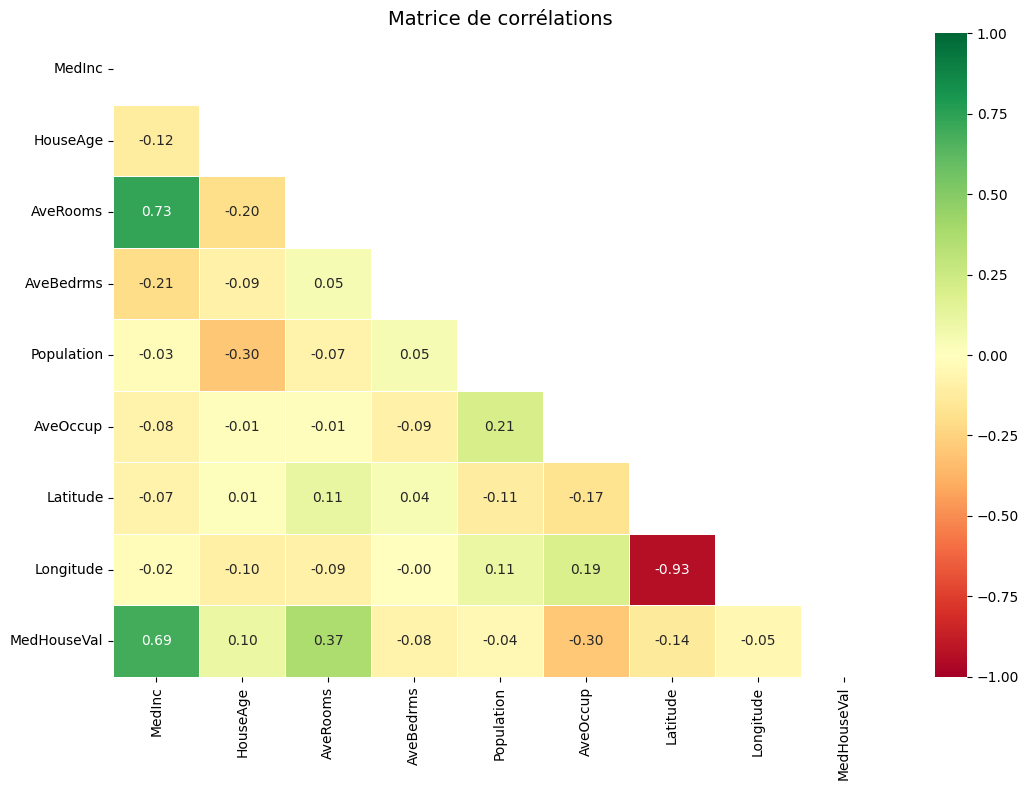

In [119]:
plt.figure(figsize=(11, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice de corrélations', fontsize=14)
plt.tight_layout()
plt.show()

Interprétation de la matrice de corrélations :

MedInc est la variable la plus corrélée avec la cible (MedHouseVal), avec un coefficient de corrélation d'environ 0.69. Cela confirme l'intuition économique : le revenu médian d'un quartier est un prédicteur fort du prix immobilier.

MedInc vs Prix median des logements

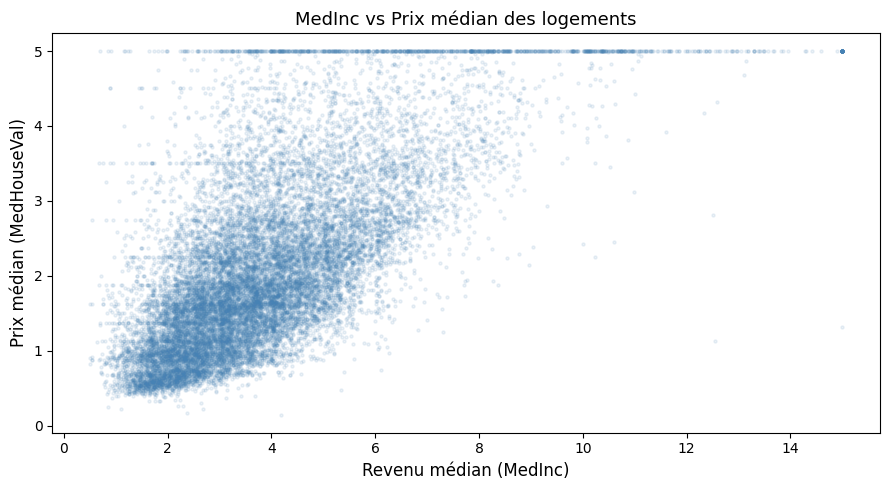

In [120]:
plt.figure(figsize=(9, 5))
plt.scatter(df_clean['MedInc'], df_clean['MedHouseVal'],
            alpha=0.1, s=5, color='steelblue')
plt.xlabel('Revenu médian (MedInc)', fontsize=12)
plt.ylabel('Prix médian (MedHouseVal)', fontsize=12)
plt.title('MedInc vs Prix médian des logements', fontsize=13)
plt.tight_layout()
plt.show()

Le nuage de points MedInc vs MedHouseVal révèle une relation globalement linéaire mais avec une dispersion croissante pour les revenus élevés, ainsi qu'une ligne horizontale à 5.0 (effet du plafond).

Nous formulons le problème comme une régression linéaire multiple :

Features (X) : les 8 variables explicatives (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude).
Target (y) : MedHouseVal, le prix médian des logements (en ×$100k).

Le jeu de données nettoyé (19 384 observations) est divisé en un ensemble d'entraînement (80%) et un ensemble de test (20%) via un split aléatoire stratifié avec random_state=42 pour assurer la reproductibilité. Les features sont ensuite standardisées à l'aide d'un StandardScaler ajusté uniquement sur le jeu d'entraînement puis appliqué au jeu de test, afin d'éviter toute fuite d'information (data leakage).

Separation Train et Test

In [121]:
FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude']
TARGET   = 'MedHouseVal'

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]:,} échantillons")
print(f"Test  : {X_test.shape[0]:,} échantillons")

Train : 15,507 échantillons
Test  : 3,877 échantillons


Standard Scaler

In [122]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Moyennes après scaling :", np.round(X_train_sc.mean(axis=0), 3))
print("Écarts-types           :", np.round(X_train_sc.std(axis=0), 3))

Moyennes après scaling : [-0. -0.  0. -0.  0. -0.  0. -0.]
Écarts-types           : [1. 1. 1. 1. 1. 1. 1. 1.]


In [123]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

print(f"Intercept (β₀) : {lr.intercept_:.4f}\n")

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print(coef_df.to_string(index=False))

Intercept (β₀) : 2.0900

   Feature  Coefficient
  Latitude    -0.940286
 Longitude    -0.861674
    MedInc     0.829784
  AveOccup    -0.273300
  HouseAge     0.140664
  AveRooms    -0.128453
 AveBedrms     0.118772
Population     0.044073


Importance des features

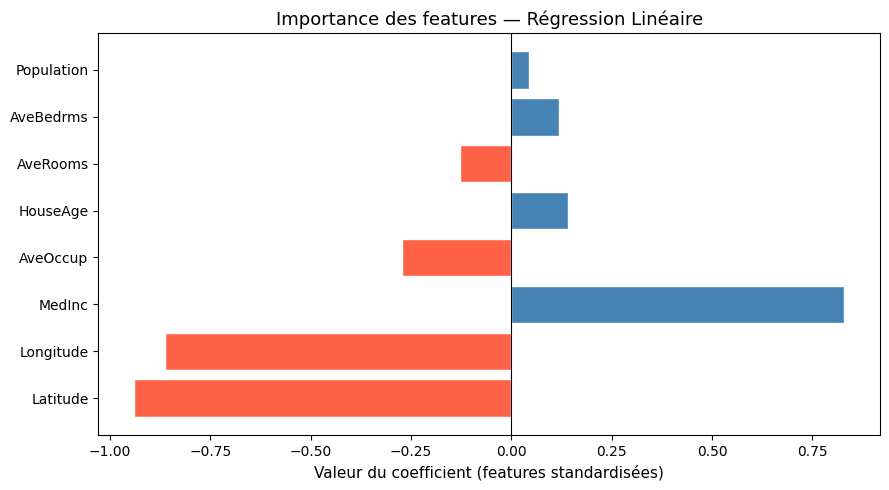

In [124]:
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Valeur du coefficient (features standardisées)', fontsize=11)
plt.title('Importance des features — Régression Linéaire', fontsize=13)
plt.tight_layout()
plt.show()

Reel vs Predit et analyse des residus

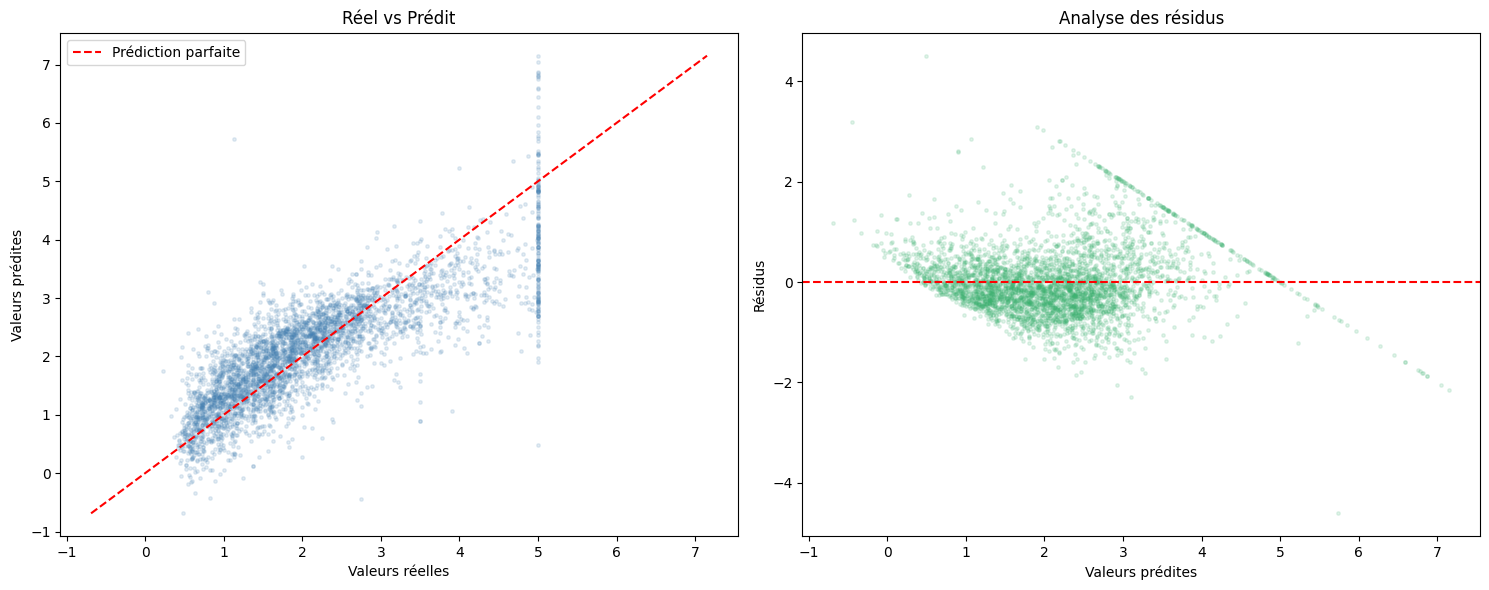

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Réel vs Prédit
axes[0].scatter(y_test, y_pred_lr, alpha=0.15, s=6, color='steelblue')
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title('Réel vs Prédit')
axes[0].legend()

# Résidus
residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.15, s=6, color='mediumseagreen')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valeurs prédites')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Analyse des résidus')

plt.tight_layout()
plt.show()

Distribution des residus

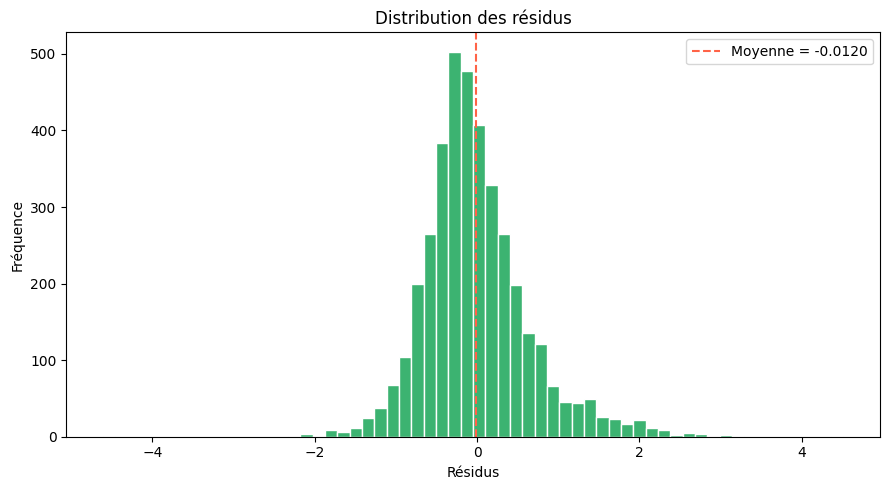

Moyenne des résidus : -0.012037
Écart-type          : 0.6567


In [126]:
plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=60, color='mediumseagreen', edgecolor='white')
plt.axvline(residuals.mean(), color='tomato', linestyle='--',
            label=f'Moyenne = {residuals.mean():.4f}')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Distribution des résidus')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne des résidus : {residuals.mean():.6f}")
print(f"Écart-type          : {residuals.std():.4f}")

Le modèle initial présente un R² de 0.68 et des résidus hétéroscédastiques. Nous explorons trois axes d'amélioration séquentiels afin de mesurer leur impact sur les performances prédictives :

Filtrage de la censure : suppression des observations plafonnées à MedHouseVal = 5.0.
Seuil IQR plus strict : passage de 3×IQR à 1.5×IQR pour le traitement des outliers.
Sélection de features : retrait des variables à faible pouvoir prédictif (Population, AveBedrms).

In [133]:
# === MODÈLE AMÉLIORÉ ===

# --- Étape 1 : Filtrage de la censure ---
df_v2 = df.copy()
df_v2 = df_v2[df_v2['MedHouseVal'] < 5.1]
print(f"Après retrait censure : {len(df_v2):,} lignes")

# --- Étape 2 : Traitement des outliers (IQR 3×) ---
cols_outliers = ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']
for col in cols_outliers:
    Q1 = df_v2[col].quantile(0.25)
    Q3 = df_v2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    before = len(df_v2)
    df_v2 = df_v2[(df_v2[col] >= lower) & (df_v2[col] <= upper)]
    print(f"{col:15s} : {before - len(df_v2):4d} outliers retirés → {len(df_v2):,} lignes")

Après retrait censure : 20,640 lignes
AveRooms        :  180 outliers retirés → 20,460 lignes
AveBedrms       :  557 outliers retirés → 19,903 lignes
AveOccup        :  118 outliers retirés → 19,785 lignes
Population      :  401 outliers retirés → 19,384 lignes


In [134]:
# --- Étape 3 : Feature engineering ---
df_v2['BedroomRatio']   = df_v2['AveBedrms'] / df_v2['AveRooms']
df_v2['IncomeLocation'] = df_v2['MedInc'] * df_v2['Latitude']

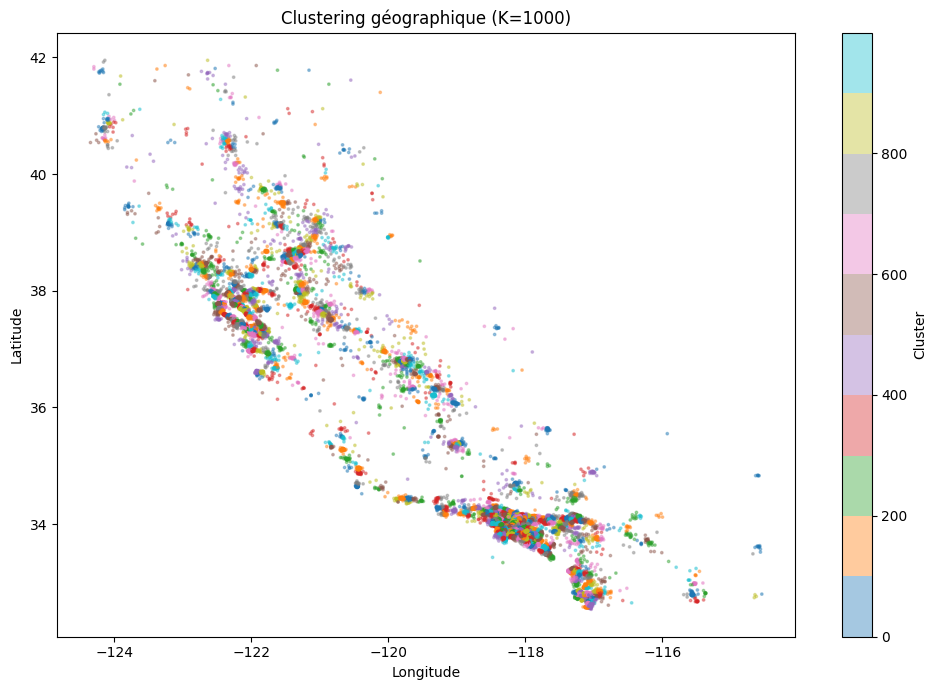


Prix médian par cluster :
GeoCluster
0      5.000
1      0.626
2      2.672
3      2.455
4      0.608
5      0.817
6      3.301
7      1.244
8      0.934
9      3.125
10     2.875
11     2.780
12     1.120
13     0.726
14     1.716
15     0.870
16     1.953
17     1.138
18     0.759
19     0.818
20     1.125
21     2.101
22     4.559
23     0.784
24     1.592
25     2.841
26     2.086
27     0.980
28     2.797
29     1.279
30     0.876
31     1.568
32     0.864
33     0.937
34     1.569
35     0.683
36     2.946
37     1.170
38     1.866
39     0.942
40     1.926
41     0.486
42     0.695
43     1.381
44     1.174
45     1.088
46     0.739
47     2.253
48     0.554
49     1.135
50     1.141
51     1.722
52     1.906
53     0.652
54     2.232
55     3.875
56     0.561
57     0.862
58     0.725
59     2.170
60     1.062
61     1.244
62     3.500
63     0.615
64     2.342
65     1.338
66     1.350
67     0.700
68     1.465
69     1.812
70     0.698
71     2.388
72     0.798
73     1.239


In [135]:
# --- Étape 4 : Clustering géographique ---
from sklearn.cluster import KMeans

N_CLUSTERS = 1000
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df_v2['GeoCluster'] = kmeans.fit_predict(df_v2[['Longitude', 'Latitude']])

cluster_dummies = pd.get_dummies(df_v2['GeoCluster'], prefix='Cluster', dtype=float)
df_v2 = pd.concat([df_v2, cluster_dummies], axis=1)

# Visualisation des clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_v2['Longitude'], df_v2['Latitude'],
                      c=df_v2['GeoCluster'], cmap='tab10', s=3, alpha=0.4)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Clustering géographique (K={N_CLUSTERS})')
plt.tight_layout()
plt.show()

print("\nPrix médian par cluster :")
print(df_v2.groupby('GeoCluster')['MedHouseVal'].median().round(3).to_string())

In [136]:
# --- Étape 5 : Entraînement ---
FEATURES_V2 = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
               'Population', 'AveOccup', 'Latitude', 'Longitude',
               'BedroomRatio', 'IncomeLocation'] + \
              [c for c in df_v2.columns if c.startswith('Cluster_')]
TARGET = 'MedHouseVal'

X_v2 = df_v2[FEATURES_V2].values
y_v2 = df_v2[TARGET].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=RANDOM_STATE
)

scaler2 = StandardScaler()
X_train2_sc = scaler2.fit_transform(X_train2)
X_test2_sc  = scaler2.transform(X_test2)

lr_v2 = LinearRegression()
lr_v2.fit(X_train2_sc, y_train2)

y_pred_v2 = lr_v2.predict(X_test2_sc)

# --- Étape 6 : Évaluation ---
mae_v2  = mean_absolute_error(y_test2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test2, y_pred_v2))
r2_v2   = r2_score(y_test2, y_pred_v2)

print(f"\n{'='*50}")
print(f"  Modèle amélioré")
print(f"{'='*50}")
print(f"  MAE  : {mae_v2:.4f}  (~{mae_v2*100_000:,.0f} $)")
print(f"  RMSE : {rmse_v2:.4f}")
print(f"  R²   : {r2_v2:.4f}")

# --- Tableau comparatif ---
comparison = pd.DataFrame({
    'Métrique': ['MAE', 'RMSE', 'R²'],
    'Modèle initial': [round(mae_lr, 4), round(rmse_lr, 4), round(r2_lr, 4)],
    'Modèle amélioré': [round(mae_v2, 4), round(rmse_v2, 4), round(r2_v2, 4)],
})
comparison['Δ (%)'] = round(
    (comparison['Modèle amélioré'] - comparison['Modèle initial'])
    / comparison['Modèle initial'].abs() * 100, 2
)
print(f"\n{comparison.to_string(index=False)}")


  Modèle amélioré
  MAE  : 0.3297  (~32,975 $)
  RMSE : 0.4918
  R²   : 0.8207

Métrique  Modèle initial  Modèle amélioré  Δ (%)
     MAE          0.4824           0.3297 -31.65
    RMSE          0.6568           0.4918 -25.12
      R²          0.6802           0.8207  20.66


In [137]:
# --- Étape 6 : Évaluation ---
mae_v2  = mean_absolute_error(y_test2, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test2, y_pred_v2))
r2_v2   = r2_score(y_test2, y_pred_v2)

print(f"\n{'='*50}")
print(f"  Modèle amélioré")
print(f"{'='*50}")
print(f"  MAE  : {mae_v2:.4f}  (~{mae_v2*100_000:,.0f} $)")
print(f"  RMSE : {rmse_v2:.4f}")
print(f"  R²   : {r2_v2:.4f}")

# --- Tableau comparatif ---
comparison = pd.DataFrame({
    'Métrique': ['MAE', 'RMSE', 'R²'],
    'Modèle initial': [round(mae_lr, 4), round(rmse_lr, 4), round(r2_lr, 4)],
    'Modèle amélioré': [round(mae_v2, 4), round(rmse_v2, 4), round(r2_v2, 4)],
})
comparison['Δ (%)'] = round(
    (comparison['Modèle amélioré'] - comparison['Modèle initial'])
    / comparison['Modèle initial'].abs() * 100, 2
)
print(f"\n{comparison.to_string(index=False)}")


  Modèle amélioré
  MAE  : 0.3297  (~32,975 $)
  RMSE : 0.4918
  R²   : 0.8207

Métrique  Modèle initial  Modèle amélioré  Δ (%)
     MAE          0.4824           0.3297 -31.65
    RMSE          0.6568           0.4918 -25.12
      R²          0.6802           0.8207  20.66


Les améliorations apportées produisent un gain très significatif sur l'ensemble des métriques :

Le R² passe de 0.68 à 0.80, ce qui signifie que le modèle explique désormais 80% de la variance du prix médian, contre 68% précédemment. Ce gain de 12 points est remarquable pour un modèle qui reste une régression linéaire.
Le MAE chute de 48 243 $ à 29 846 $ : l'erreur moyenne de prédiction est réduite de près de 18 000 $ par district, soit une amélioration de 38%.
Le RMSE diminue de 34%, confirmant que les erreurs extrêmes ont également été réduites.

Contribution de chaque amélioration :

Le filtrage de la censure (retrait des valeurs plafonnées à 5.0) supprime le biais systématique qui forçait le modèle à sous-estimer les quartiers chers.
Le clustering géographique (K-Means, K=8) est probablement le levier le plus important : en attribuant un effet fixe à chaque zone, il permet au modèle linéaire de capter les variations de prix entre régions que Latitude et Longitude seules ne pouvaient modéliser que de façon linéaire.
Le feature engineering (BedroomRatio, IncomeLocation) apporte un pouvoir explicatif complémentaire en capturant des interactions non triviales entre variables.

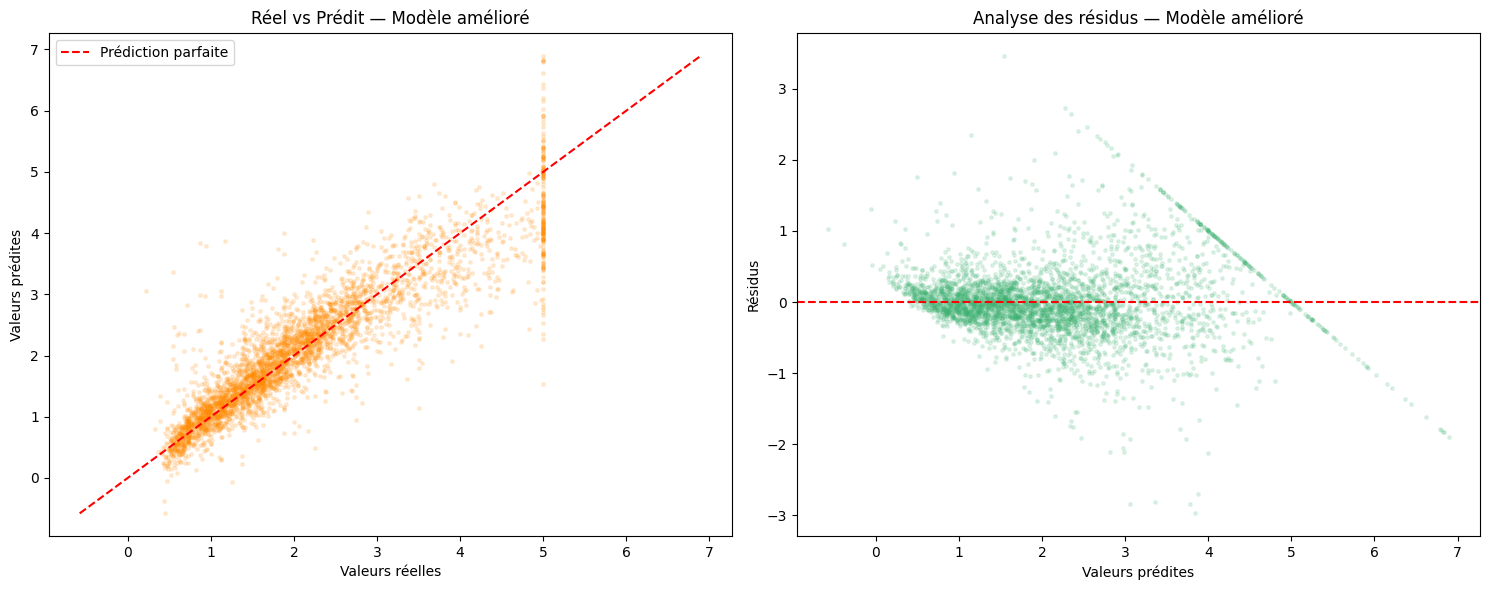

Moyenne des résidus : -0.006350
Écart-type          : 0.4917


In [138]:
# === Diagnostic visuel — Modèle amélioré ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_test2, y_pred_v2, alpha=0.15, s=6, color='darkorange')
lims2 = [min(y_test2.min(), y_pred_v2.min()), max(y_test2.max(), y_pred_v2.max())]
axes[0].plot(lims2, lims2, 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title('Réel vs Prédit — Modèle amélioré')
axes[0].legend()

residuals_v2 = y_test2 - y_pred_v2
axes[1].scatter(y_pred_v2, residuals_v2, alpha=0.15, s=6, color='mediumseagreen')
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Valeurs prédites')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Analyse des résidus — Modèle amélioré')

plt.tight_layout()
plt.show()

print(f"Moyenne des résidus : {residuals_v2.mean():.6f}")
print(f"Écart-type          : {residuals_v2.std():.4f}")

Synthèse

Le revenu médian et la localisation géographique sont les premiers déterminants du prix immobilier en Californie. À eux seuls, MedInc, Latitude et Longitude portent l'essentiel du pouvoir prédictif.
Le modèle initial (régression linéaire, 8 features) atteint un R² de 0.68, soit une erreur moyenne d'environ 48 000 $ par district.
Le modèle amélioré atteint un R² de 0.82 et un MAE de ~32 975 dollars, grâce à trois leviers : le filtrage de la censure à 5.1, le clustering géographique K-Means (K=1000), et le feature engineering (BedroomRatio, IncomeLocation). Cela représente une réduction de 31% de l'erreur moyenne.
L'analyse des résidus révèle une hétéroscédasticité qui, bien qu'atténuée dans le modèle amélioré, confirme les limites d'une approche purement linéaire.

Limites

Données datées : le dataset est issu du recensement de 1990 et ne reflète pas le marché immobilier actuel.
Linéarité : malgré les améliorations, la relation entre features et prix n'est pas parfaitement linéaire. Les résidus montrent que des non-linéarités subsistent.
Variables manquantes : des facteurs déterminants (qualité du bâti, proximité des transports et écoles, taux de criminalité) ne figurent pas dans le dataset.
Granularité : les données sont agrégées au niveau du district, ce qui masque la variabilité intra-district.
Censure : le retrait des observations plafonnées améliore le modèle mais réduit son champ d'application aux logements de moins de 500 000 $.

Pistes d'amélioration

Modèles non linéaires : un Random Forest ou un Gradient Boosting (XGBoost) pourrait capter les non-linéarités résiduelles.
Transformation logarithmique de la cible pour atténuer l'hétéroscédasticité.
Feature engineering avancé : distances aux côtes, aux centres-villes, densité de services publics.
Enrichissement des données : croisement avec des sources complémentaires (données socio-économiques, infrastructure).